# Notebook 05 — Exploratory Analysis
### WID2003 Cognitive Science | FSKTM, Universiti Malaya

---

## Overview

Before building predictive models, we **visualize and statistically test** whether eye-tracking features actually differ between High and Low performers. If no features show meaningful group differences, there is no signal for the classifier to learn from.

**Inputs**
| File | Description |
|---|---|
| `data/processed/dataset_final.parquet` | Wide-format, scaled and unscaled feature columns |
| `data/processed/labels.csv` | Performance labels per participant |
| `data/processed/raw_gaze_clean.parquet` | Raw fixation coordinates for scanpath plotting |

**Outputs**
| File | Description |
|---|---|
| `outputs/figures/05_*.png` | Distribution plots, violin plots, scanpath overlay, heatmap, effect size chart |
| `outputs/reports/05_mann_whitney_results.csv` | Statistical test results per feature |

---

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why **exploratory analysis precedes modelling** and what it reveals that model accuracy alone cannot
2. Interpret a **violin plot** and compare it to a box plot — when is one more informative than the other?
3. Apply the **Mann-Whitney U test** as a non-parametric alternative to the t-test and interpret its output (U statistic, p-value, effect size)
4. Explain **multiple comparisons correction** (Bonferroni and FDR/Benjamini-Hochberg) and describe why it is essential when testing dozens of features simultaneously
5. Describe the **rank-biserial correlation** as an effect size measure and interpret its magnitude (small ≈ 0.1, medium ≈ 0.3, large ≈ 0.5)
6. Reconstruct a participant's **scanpath** from fixation coordinates and explain what it reveals about visual search strategy

---

## Background

### Why Explore Before Modelling?

Running a classifier without first understanding the data can produce misleading results:
- A model may achieve high accuracy by exploiting an irrelevant feature that happens to correlate with label (spurious correlation)
- If no features differ significantly between groups, the model's apparent performance is likely noise
- EDA reveals data quality issues (outliers, implausible values, missing data patterns) that must be addressed before modelling

### Violin Plots

A **violin plot** combines a box plot with a kernel density estimate. The width of the violin at each value shows how many data points have that value — making the shape of the distribution visible, unlike a box plot which only shows quartiles.

For small N (< 30), individual data points should also be shown (use `inner='point'` or overlay a strip plot).

### Mann-Whitney U Test

The **Mann-Whitney U test** (also called the Wilcoxon rank-sum test) tests whether one group tends to have higher values than another without assuming normality. This is appropriate for eye-tracking data, which is typically right-skewed.

```
H₀: The two groups are drawn from the same distribution
H₁: One group tends to have higher values
```

The **rank-biserial correlation** r converts the U statistic to a standardised effect size:

```
r = 1 − (2U) / (n₁ × n₂)     |r| range: 0 (no effect) to 1 (perfect separation)
```

| |r| | Interpretation |
|---|---|
| < 0.1 | Negligible |
| 0.1 – 0.3 | Small |
| 0.3 – 0.5 | Medium |
| > 0.5 | Large |

### Multiple Comparisons Problem

When testing 100 features at α = 0.05, we expect **5 false positives by chance** even if no features truly differ. Two common corrections:

| Method | How it works | When to use |
|---|---|---|
| **Bonferroni** | Divide α by number of tests | Conservative; use when few tests and false positives are very costly |
| **FDR (Benjamini-Hochberg)** | Controls the proportion of false discoveries | Less conservative; preferred in exploratory analysis with many features |

### Scanpath Visualisation

A **scanpath** traces the sequence of fixation points over time. Each circle represents one fixation; circle size encodes fixation duration. The connecting lines show the order of fixation transitions (saccades).

High-performing students are hypothesised to show:
- More direct paths toward the `answer` AOI
- Fewer and shorter fixations on distractor regions (`M1`–`M15`)
- Earlier first fixation on the correct region

### Spearman Correlation Heatmap

Spearman correlation is used (instead of Pearson) because eye-tracking features are rarely normally distributed. The heatmap shows **collinearity** between features — highly correlated features (|r| > 0.8) are redundant, and including both can destabilise some classifiers (particularly Logistic Regression).

---

## Discussion Questions

1. Two features have significant Mann-Whitney p-values (p < 0.05) but very different effect sizes: |r| = 0.12 and |r| = 0.48. Which is more useful for a classifier? Why is p-value alone not sufficient for selecting features?
2. You run Mann-Whitney tests on 80 features and find 12 are significant at p < 0.05. After FDR correction, only 3 remain significant. What does this mean, and how should it change your interpretation?
3. The scanpath of a Low-performing participant visits the `answer` AOI early but then looks away and returns multiple times. Does this mean they found the answer? What other metrics would you check to confirm?
4. The Spearman heatmap shows `correct_aoi_dwell_ratio` and `Total_duration_of_fixations_correct` are highly correlated (r = 0.87). Should both be included in the model? What are the risks of including redundant features?
5. EDA shows that `mean_time_to_first_click` is significantly lower for High performers on 6 out of 8 tasks, but not on `whoCheats` and `whoThief`. What does this suggest about those tasks, and how might task difficulty affect the validity of a single composite performance label?

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

from src.config import (
    DATASET_FINAL, LABELS_CSV, RAWGAZE_CLEAN_PKL, OUTPUTS_FIGURES,
    PERFORMANCE_LABEL_COL, TASKS, ExportCols
)

sns.set_theme(style='whitegrid', palette='Set2')
OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)

LABEL_COLORS = {1: '#2ecc71', 0: '#e74c3c'}
LABEL_NAMES  = {1: 'High', 0: 'Low'}

## 1. Load data

In [2]:
dataset = pd.read_parquet(DATASET_FINAL)
labels  = pd.read_csv(LABELS_CSV)
gaze    = pd.read_parquet(RAWGAZE_CLEAN_PKL)

# Use unscaled features for EDA
unscaled_cols = [c for c in dataset.columns if c.endswith('_unscaled')]
meta_cols = ['participant_id', PERFORMANCE_LABEL_COL, 'speed_label', 'accuracy_rate',
             'total_score', 'split']
meta_cols = [c for c in meta_cols if c in dataset.columns]

df = dataset[meta_cols + unscaled_cols].copy()
# Strip '_unscaled' suffix for display
df.columns = [c.replace('_unscaled', '') for c in df.columns]

feature_cols = [c for c in df.columns if c not in meta_cols]
print(f"Participants: {len(df)}, Feature columns: {len(feature_cols)}")

Participants: 4, Feature columns: 230


## 2. Class distribution

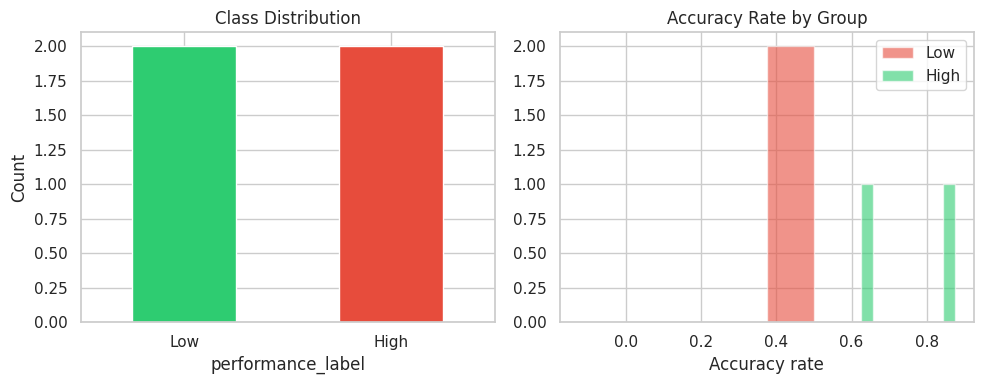

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Class counts
counts = df[PERFORMANCE_LABEL_COL].map(LABEL_NAMES).value_counts()
colors = [LABEL_COLORS[k] for k in df[PERFORMANCE_LABEL_COL].map(LABEL_NAMES).value_counts().index.map({v: k for k, v in LABEL_NAMES.items()})]
counts.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'][:len(counts)], edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Accuracy histogram by group
for label, grp in df.groupby(PERFORMANCE_LABEL_COL):
    axes[1].hist(grp['accuracy_rate'], bins=8, alpha=0.6,
                 color=LABEL_COLORS[label], label=LABEL_NAMES[label], edgecolor='white')
axes[1].set_title('Accuracy Rate by Group')
axes[1].set_xlabel('Accuracy rate')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '05_class_distribution.png', dpi=150)
plt.show()

## 3. Violin plots of key features by group

/tmp/ipykernel_72420/1845582482.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_72420/1845582482.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_72420/1845582482.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_72420/1845582482.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_72420/1845582482.py:27: F

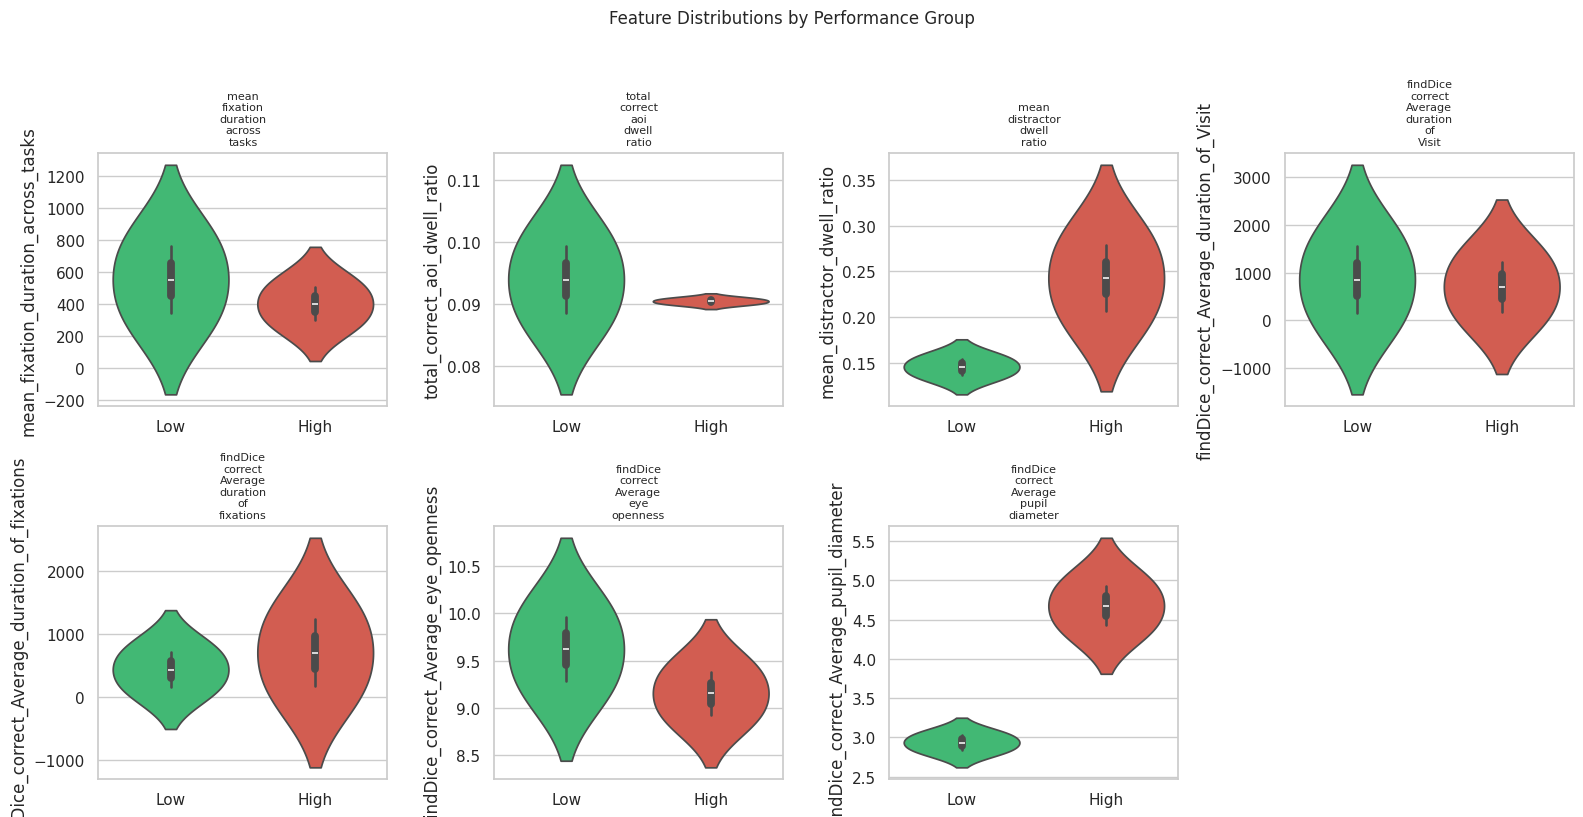

In [4]:
# Select key features for display (use aggregate/cross-task features if available)
key_features = [c for c in [
    'mean_fixation_duration_across_tasks',
    'total_correct_aoi_dwell_ratio',
    'mean_time_to_first_click',
    'mean_distractor_dwell_ratio',
] if c in df.columns]

# Also try per-task features for a specific task
sample_task_feats = [c for c in feature_cols if 'findDice' in c and 'correct' in c][:4]
display_features = key_features + sample_task_feats

if not display_features:
    display_features = feature_cols[:8]

n = len(display_features)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 4))
axes = np.array(axes).flatten()

plot_df = df[[PERFORMANCE_LABEL_COL] + display_features].copy()
plot_df[PERFORMANCE_LABEL_COL] = plot_df[PERFORMANCE_LABEL_COL].map(LABEL_NAMES)

for i, feat in enumerate(display_features):
    sns.violinplot(
        data=plot_df, x=PERFORMANCE_LABEL_COL, y=feat,
        palette=list(LABEL_COLORS.values()), ax=axes[i], inner='box'
    )
    axes[i].set_title(feat.replace('_', '\n'), fontsize=8)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Performance Group', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '05_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correct AOI dwell ratio per task — main interpretive plot

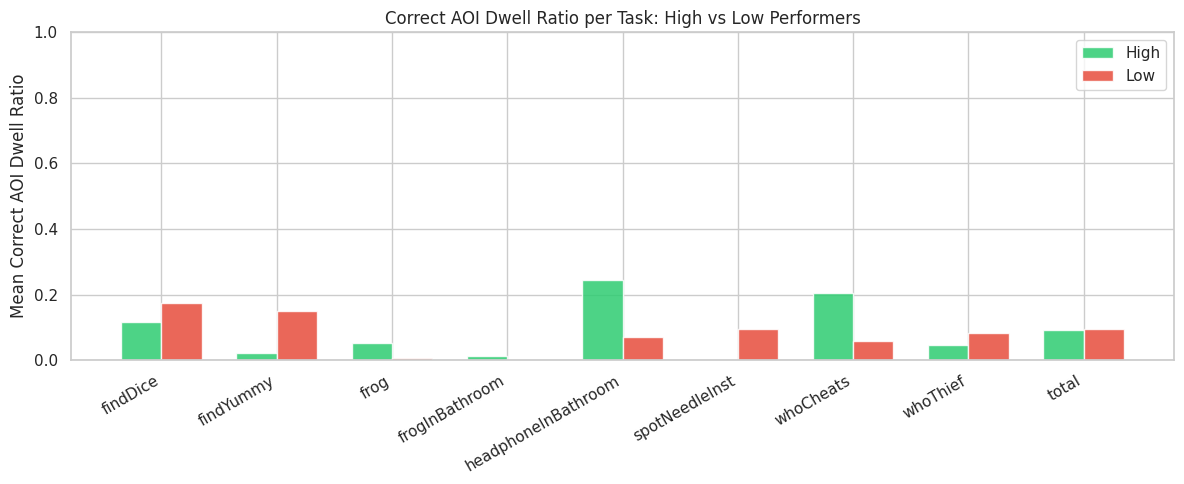

In [5]:
dwell_cols = [c for c in df.columns if 'correct_aoi_dwell_ratio' in c]

if dwell_cols:
    dwell_data = []
    for col in dwell_cols:
        task_name = col.split('_correct_aoi')[0]
        for label, grp in df.groupby(PERFORMANCE_LABEL_COL):
            dwell_data.append({
                'task': task_name,
                'group': LABEL_NAMES[label],
                'mean_dwell': grp[col].mean()
            })

    dwell_df = pd.DataFrame(dwell_data)

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(dwell_cols))
    width = 0.35
    task_labels = [c.split('_correct_aoi')[0] for c in dwell_cols]

    for i, (label, group_name, color) in enumerate([(1,'High','#2ecc71'), (0,'Low','#e74c3c')]):
        grp_data = dwell_df[dwell_df['group'] == group_name]['mean_dwell'].values
        ax.bar(x + i*width, grp_data[:len(x)], width, label=group_name, color=color, alpha=0.85)

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(task_labels, rotation=30, ha='right')
    ax.set_ylabel('Mean Correct AOI Dwell Ratio')
    ax.set_title('Correct AOI Dwell Ratio per Task: High vs Low Performers')
    ax.legend()
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURES / '05_dwell_ratio_per_task.png', dpi=150)
    plt.show()
else:
    print("No correct AOI dwell ratio columns found.")

## 5. Scanpath visualization (one High vs one Low participant)

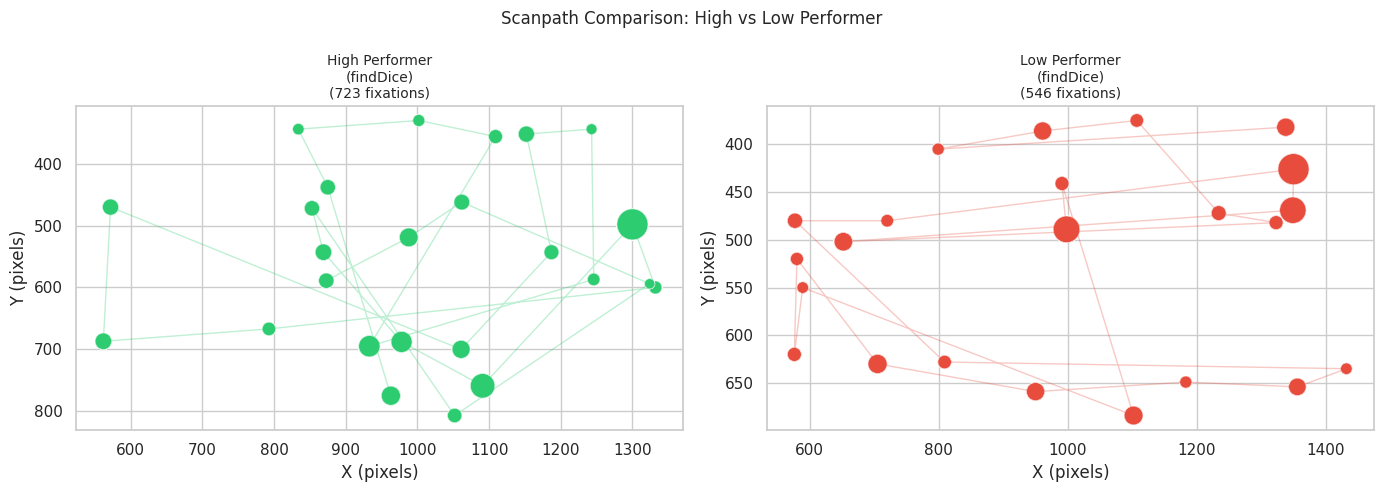

In [6]:
# Select representative participants
high_ids = df[df[PERFORMANCE_LABEL_COL] == 1]['participant_id'].values
low_ids  = df[df[PERFORMANCE_LABEL_COL] == 0]['participant_id'].values

SAMPLE_TASK = TASKS[0]  # Use first task for visualization

def plot_scanpath(ax, participant_id, task, gaze_df, title, color):
    p_gaze = gaze_df[
        (gaze_df[ExportCols.PARTICIPANT_NAME] == participant_id) &
        (gaze_df[ExportCols.PRESENTED_MEDIA].str.contains(task, na=False, case=False)) &
        (gaze_df[ExportCols.EYE_MOVEMENT_TYPE] == 'Fixation')
    ].dropna(subset=[ExportCols.FIXATION_X, ExportCols.FIXATION_Y, ExportCols.EYE_MOVEMENT_DURATION])

    if len(p_gaze) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    # Normalize duration for circle sizes
    sizes = (p_gaze[ExportCols.EYE_MOVEMENT_DURATION] / p_gaze[ExportCols.EYE_MOVEMENT_DURATION].max() * 500).clip(20, 500)

    ax.scatter(
        p_gaze[ExportCols.FIXATION_X],
        p_gaze[ExportCols.FIXATION_Y],
        s=sizes, c=color, alpha=0.6, edgecolors='white', linewidths=0.5
    )
    # Draw scanpath lines
    ax.plot(
        p_gaze[ExportCols.FIXATION_X].values,
        p_gaze[ExportCols.FIXATION_Y].values,
        color=color, alpha=0.3, linewidth=1
    )
    ax.invert_yaxis()  # screen coordinates: Y increases downward
    ax.set_title(f"{title}\n({len(p_gaze)} fixations)", fontsize=10)
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(high_ids) > 0:
    plot_scanpath(axes[0], high_ids[0], SAMPLE_TASK, gaze, f'High Performer\n({SAMPLE_TASK})', '#2ecc71')
if len(low_ids) > 0:
    plot_scanpath(axes[1], low_ids[0], SAMPLE_TASK, gaze, f'Low Performer\n({SAMPLE_TASK})', '#e74c3c')

plt.suptitle('Scanpath Comparison: High vs Low Performer', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '05_scanpath_comparison.png', dpi=150)
plt.show()

## 6. Correlation heatmap

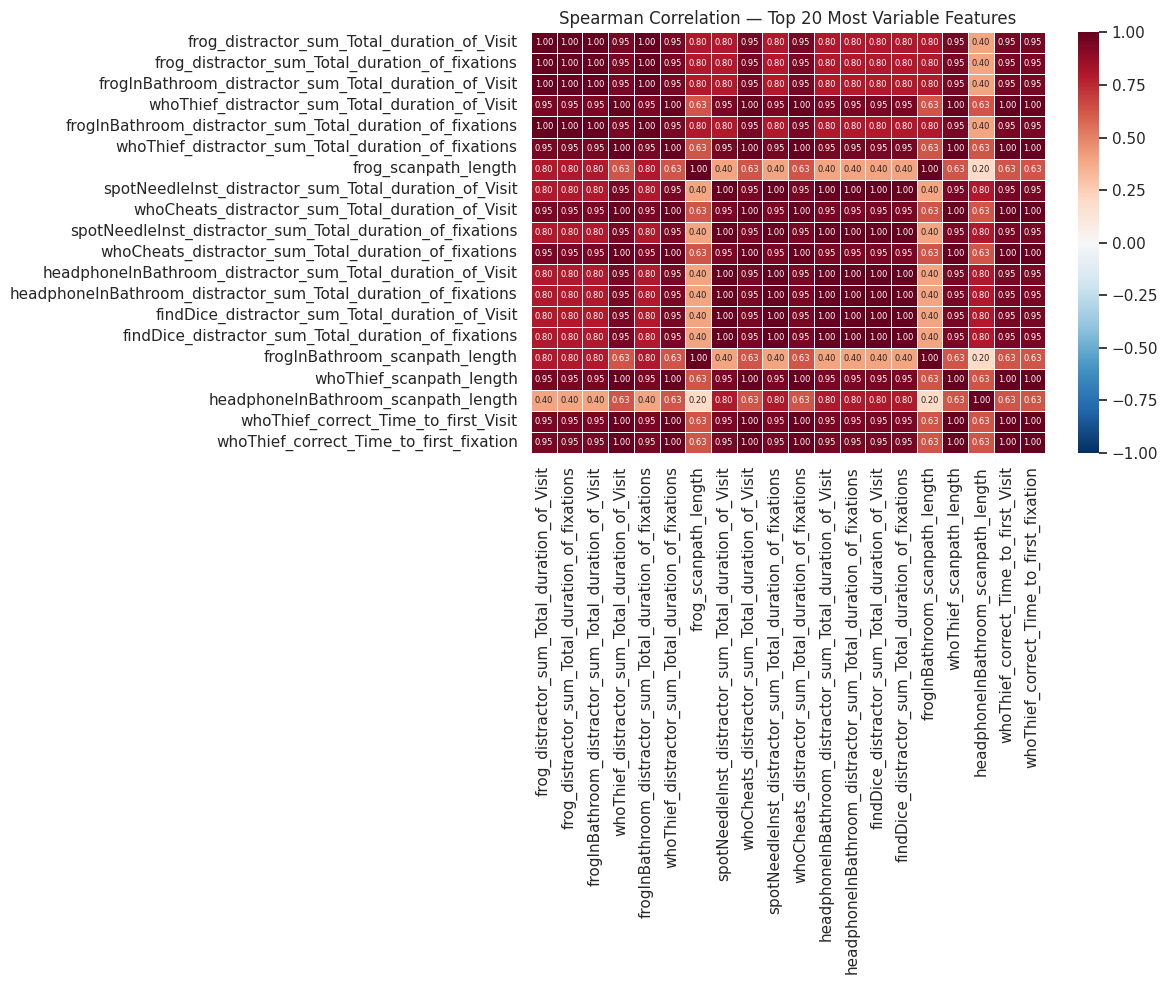

In [7]:
# Select top 20 most variable features
top_feats = df[feature_cols].std().nlargest(20).index.tolist()

corr = df[top_feats].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 6},
    linewidths=0.5
)
ax.set_title('Spearman Correlation — Top 20 Most Variable Features')
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Mann-Whitney U test per feature

In [8]:
high_group = df[df[PERFORMANCE_LABEL_COL] == 1]
low_group  = df[df[PERFORMANCE_LABEL_COL] == 0]

MIN_GROUP_SIZE = 2  # Mann-Whitney requires at least 2 per group
n_high, n_low = len(high_group), len(low_group)
print(f"Group sizes — High: {n_high}, Low: {n_low}")
if n_high < MIN_GROUP_SIZE or n_low < MIN_GROUP_SIZE:
    print("WARNING: Groups too small for statistical testing.")

test_results = []
for feat in feature_cols:
    h = high_group[feat].dropna()
    l = low_group[feat].dropna()
    if len(h) < MIN_GROUP_SIZE or len(l) < MIN_GROUP_SIZE:
        continue
    u_stat, p_val = stats.mannwhitneyu(h, l, alternative='two-sided')

    # Rank-biserial correlation (effect size)
    n1, n2 = len(h), len(l)
    r = 1 - (2 * u_stat) / (n1 * n2)

    test_results.append({
        'feature': feat,
        'U_stat': u_stat,
        'p_value': p_val,
        'effect_size_r': abs(r),
        'high_mean': h.mean(),
        'low_mean': l.mean(),
    })

if not test_results:
    print("No features had enough data for statistical testing.")
    results_df = pd.DataFrame(columns=['feature','U_stat','p_value','effect_size_r','high_mean','low_mean','p_fdr','significant_fdr'])
else:
    results_df = pd.DataFrame(test_results).sort_values('p_value')

    # FDR correction
    reject, p_corrected, _, _ = multipletests(results_df['p_value'], method='fdr_bh')
    results_df['p_fdr'] = p_corrected
    results_df['significant_fdr'] = reject

    if n_high <= 2 or n_low <= 2:
        print(f"NOTE: With only {min(n_high, n_low)} participants per group, the minimum")
        print(f"      achievable p-value is ~{1/6:.3f} — significance thresholds are not meaningful.")
        print(f"      Interpret effect sizes (|r|) instead.")

    print(f"Features tested: {len(results_df)}")
    print(f"Significant before correction (p<0.05): {(results_df['p_value'] < 0.05).sum()}")
    print(f"Significant after FDR correction:       {results_df['significant_fdr'].sum()}")

results_df.head(20)


Group sizes — High: 2, Low: 2
NOTE: With only 2 participants per group, the minimum
      achievable p-value is ~0.167 — significance thresholds are not meaningful.
      Interpret effect sizes (|r|) instead.
Features tested: 230
Significant before correction (p<0.05): 0
Significant after FDR correction:       0


,feature,U_stat,p_value,effect_size_r,high_mean,low_mean,p_fdr,significant_fdr
31,frogInBathroom_correct_Number_of_Visits,4.0,0.193931,1.0,1.000000,0.000000,0.657033,False
23,frogInBathroom_correct_Number_of_Glances,4.0,0.193931,1.0,1.000000,0.000000,0.657033,False
39,frogInBathroom_correct_Number_of_fixations,4.0,0.193931,1.0,1.000000,0.000000,0.657033,False
190,frogInBathroom_refixation_count,4.0,0.193931,1.0,1.000000,0.000000,0.657033,False
32,headphoneInBathroom_correct_Number_of_Visits,4.0,0.220671,1.0,2.000000,0.500000,0.657033,False
56,headphoneInBathroom_correct_Number_of_saccades...,4.0,0.220671,1.0,1.500000,0.000000,0.657033,False
86,frogInBathroom_correct_Total_duration_of_Visit,4.0,0.220671,1.0,241.500000,0.000000,0.657033,False
24,headphoneInBathroom_correct_Number_of_Glances,4.0,0.220671,1.0,2.000000,0.500000,0.657033,False
102,frogInBathroom_correct_aoi_dwell_ratio,4.0,0.220671,1.0,0.011508,0.000000,0.657033,False
94,frogInBathroom_correct_Total_duration_of_fixat...,4.0,0.220671,1.0,241.500000,0.000000,0.657033,False


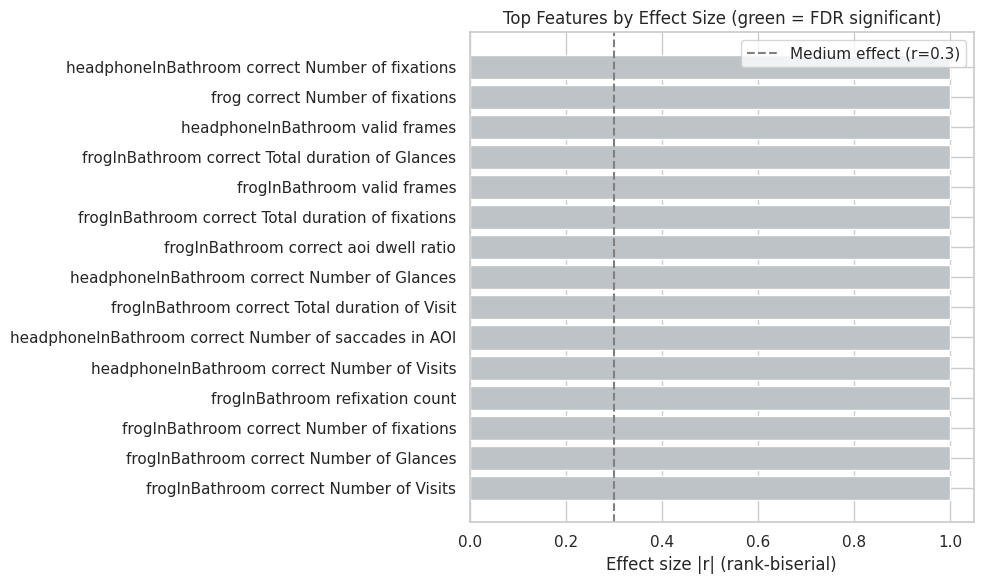

In [9]:
# Plot top features by effect size
top_sig = results_df.nlargest(15, 'effect_size_r')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if sig else '#bdc3c7' for sig in top_sig['significant_fdr']]
ax.barh(top_sig['feature'].str.replace('_', ' '), top_sig['effect_size_r'],
        color=colors, edgecolor='white')
ax.set_xlabel('Effect size |r| (rank-biserial)')
ax.set_title('Top Features by Effect Size (green = FDR significant)')
ax.axvline(0.3, color='gray', linestyle='--', label='Medium effect (r=0.3)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '05_effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
results_df.to_csv('../outputs/reports/05_mann_whitney_results.csv', index=False)
print("Saved statistical test results.")

Saved statistical test results.
